FaultyCase1: Blokering af luftlinje
1.1: 1566-5181
1.2: 657-3777
1.3: 691-3691

FaultyCase2: Blokering af vandlinje
2.1: 2244-6616
2.2: 476-2656
2.3: 331-2467

FaultyCase3: Blokering ved separator indgangen
3.1: 1136-8352
3.2: 333-5871
3.3: 596-9566

FaultyCase4: Lækage (åben bypass)
4.1: 953-6294
4.2: 851-3851
4.3: 241-3241

FaultyCase5: Slugging (ustabile væskebælger i rørene)
5.1: Fault1 686-1172, Fault2 1772-2253
5.2: Fault 1 1633-2955, Fault2 7031-7553, Fault3 8057-10608

FaultyCase6: Uønsker tryksætning af en isoleret rørledning
6.1: 1723-2800
6.2: 1037-4830

## Data import

Vi finder projektmappen, tilføjer den til sys.path, importerer biblioteker og loader FaultyCase1.mat

Loader Set1_1, Set1_2 og Set1_3 som TimeSeriesDataset-objekter og fault_info gemmer fault-start og fault-end for hvert datasæt

In [14]:
import sys
from pathlib import Path

cwd = Path.cwd()

while not ((cwd / "data").exists() or (cwd / "CVACaseStudy").exists()):
    if cwd.parent == cwd:
        raise RuntimeError("Kunne ikke finde projekt root")
    cwd = cwd.parent

PROJECT_ROOT = cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

from fdd.dataloader import DataLoader
from fdd.preprocessor import StandardPreprocessor
from fdd.dataset import TimeSeriesDataset

def find_file(root, filename):
    matches = list(root.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"{filename} not found under {root}")
    return sorted(matches, key=lambda p: len(str(p)))[0]

DATA_PATH = find_file(PROJECT_ROOT, "FaultyCase1.mat")

loader = DataLoader(DATA_PATH)
datasets = loader.load()

fault_info = {
    "Set1_1": {"start": 1566, "end": 5181, "description": "Changing conditions"},
    "Set1_2": {"start": 657, "end": 3777, "description": "Steady-state 1"},
    "Set1_3": {"start": 691, "end": 3691, "description": "Steady-state 2"},
}

for name, ds in datasets.items():
    print(name, ds.summary())

Set1_1 TimeSeriesDataset(name=Set1_1, n_samples=5811, n_features=23)
Set1_2 TimeSeriesDataset(name=Set1_2, n_samples=4467, n_features=23)
Set1_3 TimeSeriesDataset(name=Set1_3, n_samples=4321, n_features=23)


## Evalueringsfunktioner

Definerer målene til evaluering, laver en sand/falsk label serie, hvor 0 = normal og 1 = fault.

Måler fault detection performance
- Første alarm efter fault-start
- Detection delay
- Antal alarmer før, under og efter fault
- False alarm rate
- Fault detection rate 

Måler klassifikationsperformance
- Accuracy
- Precision
- Recall
- F1 score 

Denne blok er vigtig for FDA, fordi FDA er en supervised classifier

In [15]:
def make_ground_truth(n_samples, fault_start, fault_end):
    y = np.zeros(n_samples, dtype=int)
    y[fault_start:fault_end + 1] = 1
    return y


def evaluate_alarm(alarm, fault_start, fault_end):
    alarm = np.asarray(alarm).astype(bool)

    before_fault = alarm[:fault_start]
    during_fault = alarm[fault_start:fault_end + 1]
    after_fault = alarm[fault_end + 1:]

    alarm_indices_after_start = np.where(alarm[fault_start:])[0]

    if len(alarm_indices_after_start) == 0:
        first_alarm_after_fault = None
        detection_delay = None
    else:
        first_alarm_after_fault = int(alarm_indices_after_start[0] + fault_start)
        detection_delay = int(first_alarm_after_fault - fault_start)

    return {
        "first_alarm_after_fault": first_alarm_after_fault,
        "detection_delay": detection_delay,
        "n_alarms_total": int(alarm.sum()),
        "n_alarms_before_fault": int(before_fault.sum()),
        "n_alarms_during_fault": int(during_fault.sum()),
        "n_alarms_after_fault": int(after_fault.sum()),
        "false_alarm_rate_before_fault": float(before_fault.mean()) if len(before_fault) else np.nan,
        "fault_detection_rate": float(during_fault.mean()) if len(during_fault) else np.nan,
    }


def evaluate_classifier(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_fault": precision_score(y_true, y_pred, zero_division=0),
        "recall_fault": recall_score(y_true, y_pred, zero_division=0),
        "f1_fault": f1_score(y_true, y_pred, zero_division=0),
    }

## Shewhart

Denne blok definerer og træner Shewhart. Først vælges sensorer og derefter sættes:
- Vote_threshold = 2
- k_sigma = 3

Det betyder:
- Hver sensor bruger ±3σ-grænser
- Samlet alarm kræver mindst 2 sensorer i alarm 

fit_shewhart_models() træner kontrolgrænser ud fra healthy data før fault-start og shewhart_predict() giver alarm for en sensor, hvis den er under LCL eller over UCL. 

Shewhart_multisensor_alarm() samler alle sensoralarmer og returnerer:
- Alarm pr sensor 
- Antal sensorer i alarm
- Samlet alarm 

In [16]:
shewhart_sensors = [
    "Air_Delivery_P",
    "P_Bottom_Riser",
    "Diff_P_VC404",
    "Air_In_Flow",
    "Flow_Top_Riser",
]

vote_threshold = 2
k_sigma = 3

def fit_shewhart_models(datasets, fault_info, sensors, k=3):
    models = {}

    for sensor in sensors:
        train_parts = []

        for name, dataset in datasets.items():
            train_parts.append(dataset.sensors.loc[:fault_info[name]["start"] - 1, sensor])

        train_sensor = pd.concat(train_parts, ignore_index=True).interpolate().ffill().bfill()

        mu = train_sensor.mean()
        sigma = train_sensor.std(ddof=0)

        models[sensor] = {
            "CL": mu,
            "sigma": sigma,
            "LCL": mu - k * sigma,
            "UCL": mu + k * sigma,
        }

    return models


def shewhart_predict(test_series, lcl, ucl):
    test_series = pd.Series(test_series).interpolate().ffill().bfill()
    return (test_series < lcl) | (test_series > ucl) # Returnerer en boolean Series, hvor True indikerer at værdien er uden for kontrolgrænserne


def shewhart_multisensor_alarm(dataset, models, sensors, vote_threshold=2):
    alarm_df = pd.DataFrame(index=dataset.sensors.index) # DataFrame til at gemme alarmstatus for hver sensor over tid

    for sensor in sensors:
        alarm_df[sensor] = shewhart_predict(
            dataset.sensors[sensor],
            models[sensor]["LCL"],
            models[sensor]["UCL"],
        ).values

    votes = alarm_df.sum(axis=1)
    return alarm_df, votes, votes >= vote_threshold


shewhart_models = fit_shewhart_models(
    datasets,
    fault_info,
    shewhart_sensors,
    k=k_sigma,
) # Fit Shewhart-modeller for hver sensor baseret på træningsdata, hvor k_sigma bestemmer bredden af kontrolgrænserne

## PCA

Denne blok træner PCA på healthy data:
- Samler alle samples før fault-start
- Standardiserer healthy data
- Beregner kovariansmatricen
- Finder principal components
- Vælger 7 PCA-komponenter 
- Beregner Hotelling T2-kontrolgrænsen

Tester et datasæt ved at:
- Standardisere data
- Projicere til PCA-rummet
- Beregne T2
- Give alarm hvis T2 > threshold

In [17]:
from scipy.stats import f

# ===============================
# PCA training data: healthy data
# ===============================
healthy_parts = [
    dataset.subset_rows(0, fault_info[name]["start"]).sensors
    for name, dataset in datasets.items()
]

healthy_dataset = TimeSeriesDataset(
    "Healthy_training_data",
    pd.concat(healthy_parts, ignore_index=True),
)

pca_preprocessor = StandardPreprocessor(
    with_standardization=True,
    n_lags=0,
    drop_na=True,
)

X_train = pca_preprocessor.fit_transform(healthy_dataset).to_numpy()

# ===============================
# PCA model
# ===============================
cov_matrix = np.cov(X_train.T)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

n_components = 7

P = eigenvectors[:, :n_components]
lambda_inv = np.diag(1.0 / eigenvalues[:n_components])

# ===============================
# Hotelling T2 threshold
# ===============================
n = X_train.shape[0]
a = n_components
alpha = 0.05

F_limit = f.ppf(1 - alpha, a, n - a)
T2_limit = (a * (n - 1) * (n + 1)) / (n * (n - a)) * F_limit

# ===============================
# Q-statistic / SPE threshold
# ===============================
T_train = X_train @ P
X_train_hat = T_train @ P.T
E_train = X_train - X_train_hat

Q_train = np.sum(E_train ** 2, axis=1)

Q_alpha = 0.95
Q_limit = np.quantile(Q_train, Q_alpha)

print("T2 threshold:", T2_limit)
print("Q/SPE threshold:", Q_limit)


def pca_detect(dataset):
    X = pca_preprocessor.transform(dataset).to_numpy()

    # PCA scores
    scores = X @ P

    # Hotelling T2: variation inside PCA model space
    T2 = np.sum((scores @ lambda_inv) * scores, axis=1)

    # Reconstruction from retained principal components
    X_hat = scores @ P.T

    # Residuals: variation not explained by PCA
    residuals = X - X_hat

    # Q statistic / SPE
    Q = np.sum(residuals ** 2, axis=1)

    # Alarms
    alarm_T2 = T2 > T2_limit
    alarm_Q = Q > Q_limit
    alarm_combined = alarm_T2 | alarm_Q

    return T2, Q, alarm_T2, alarm_Q, alarm_combined

T2 threshold: 14.123018031348115
Q/SPE threshold: 2.5478517498157025


## DPCA

Denne blok implementerer Dynamic PCA. DPCA er en udvidelse af PCA, hvor der laves lagged features, så modellen både bruger nuværende sensorværdier og tidligere sensorværdier.

Hvor PCA bruger:

x(t)

bruger DPCA fx:

x(t), x(t-1), x(t-2)

Derefter trænes PCA på den udvidede matrix. Det gør DPCA mere egnet til tidsseriedata, hvor procesdynamik og forsinkelser er vigtige.

- Samler healthy data før fault-start
- Laver lagged features med n_lags = 2
- Træner PCA på den laggede matrix
- Vælger antal komponenter ud fra 95% forklaret varians
- Beregner T2-threshold 
- Beregner Q/SPE threshold 
- Definerer dpca_detect(), som kan køre på hvert datasæt

In [28]:
# ===============================
# DPCA training data: healthy data
# ===============================
dpca_lag_length = 2

dpca_healthy_parts = [
    dataset.subset_rows(0, fault_info[name]["start"]).sensors
    for name, dataset in datasets.items()
]

dpca_healthy_dataset = TimeSeriesDataset(
    "Healthy_DPCA_training_data",
    pd.concat(dpca_healthy_parts, ignore_index=True),
)

dpca_preprocessor = StandardPreprocessor(
    with_standardization=True,
    n_lags=dpca_lag_length,
    drop_na=True,
)

X_train_dpca = dpca_preprocessor.fit_transform(dpca_healthy_dataset).to_numpy()

print("DPCA lag length:", dpca_lag_length)
print("DPCA training shape:", X_train_dpca.shape)

# ===============================
# DPCA model
# ===============================
dpca_cov_matrix = np.cov(X_train_dpca.T)

dpca_eigenvalues, dpca_eigenvectors = np.linalg.eig(dpca_cov_matrix)
dpca_eigenvalues = np.real(dpca_eigenvalues)
dpca_eigenvectors = np.real(dpca_eigenvectors)

dpca_idx = dpca_eigenvalues.argsort()[::-1]
dpca_eigenvalues = dpca_eigenvalues[dpca_idx]
dpca_eigenvectors = dpca_eigenvectors[:, dpca_idx]

dpca_explained_variance_ratio = dpca_eigenvalues / dpca_eigenvalues.sum()
dpca_cumulative_variance = np.cumsum(dpca_explained_variance_ratio)

dpca_variance_df = pd.DataFrame({
    "component": np.arange(1, len(dpca_eigenvalues) + 1),
    "eigenvalue": dpca_eigenvalues,
    "explained_variance_ratio": dpca_explained_variance_ratio,
    "cumulative_variance": dpca_cumulative_variance,
})

display(dpca_variance_df.head(20))

# Choose components explaining at least 95% variance
dpca_n_95 = np.argmax(dpca_cumulative_variance >= 0.95) + 1
dpca_n_components = min(dpca_n_95, X_train_dpca.shape[1] - 1)

P_dpca = dpca_eigenvectors[:, :dpca_n_components]
lambda_inv_dpca = np.diag(1.0 / dpca_eigenvalues[:dpca_n_components])

# ===============================
# DPCA Hotelling T2 threshold
# ===============================
n_dpca = X_train_dpca.shape[0]
a_dpca = dpca_n_components
alpha_dpca = 0.05

F_limit_dpca = f.ppf(1 - alpha_dpca, a_dpca, n_dpca - a_dpca)
T2_limit_dpca = (
    (a_dpca * (n_dpca - 1) * (n_dpca + 1))
    / (n_dpca * (n_dpca - a_dpca))
) * F_limit_dpca

# ===============================
# DPCA Q-statistic / SPE threshold
# ===============================
T_train_dpca = X_train_dpca @ P_dpca
X_train_hat_dpca = T_train_dpca @ P_dpca.T
E_train_dpca = X_train_dpca - X_train_hat_dpca

Q_train_dpca = np.sum(E_train_dpca ** 2, axis=1)

Q_alpha_dpca = 0.95
Q_limit_dpca = np.quantile(Q_train_dpca, Q_alpha_dpca)

print("DPCA retained components:", dpca_n_components)
print("DPCA T2 threshold:", T2_limit_dpca)
print("DPCA Q/SPE threshold:", Q_limit_dpca)


def dpca_detect(dataset):
    X = dpca_preprocessor.transform(dataset).to_numpy()

    # DPCA scores
    scores = X @ P_dpca

    # Hotelling T2: abnormal variation inside DPCA model space
    T2 = np.sum((scores @ lambda_inv_dpca) * scores, axis=1)

    # Reconstruction from retained DPCA components
    X_hat = scores @ P_dpca.T

    # Residuals: variation not explained by DPCA
    residuals = X - X_hat

    # Q statistic / SPE
    Q = np.sum(residuals ** 2, axis=1)

    # Individual alarms
    alarm_T2 = T2 > T2_limit_dpca
    alarm_Q = Q > Q_limit_dpca

    # Combined DPCA alarm
    alarm_combined = alarm_T2 | alarm_Q

    return T2, Q, alarm_T2, alarm_Q, alarm_combined

DPCA lag length: 2
DPCA training shape: (2912, 69)


,component,eigenvalue,explained_variance_ratio,cumulative_variance
0,1,26.539639,0.384500,0.384500
1,2,18.327804,0.265529,0.650029
2,3,7.467282,0.108184,0.758214
3,4,5.419065,0.078510,0.836724
4,5,3.209179,0.046494,0.883218
5,6,2.721673,0.039431,0.922649
6,7,1.274754,0.018468,0.941117
7,8,0.977672,0.014164,0.955282
8,9,0.565722,0.008196,0.963478
9,10,0.446832,0.006474,0.969951


DPCA retained components: 8
DPCA T2 threshold: 15.57550195420846
DPCA Q/SPE threshold: 7.951707941161701


## FDA

Denne blok træner den manuelle FDA-model. Først laves labeled training data, hvor healthy får label 0 og fault får label 1. 

Derefter standardiseres data og så beregnes FDA matricerne. 
Sw: Withing-class scatter
Sb: Between-class scatter
Wp: Projektionsretningen

Derefter beregnes klassemodeller i FDA-rummet og datasættet klassificeres ved at projicere det til FDA-rummet of vælge den klasse med lavest afstand. 

Returnerer: 
- Predicted class
- Alarm, hvor pred == 1


In [19]:
X_train_list = []
y_train_list = []

for name, dataset in datasets.items():
    df = dataset.sensors.copy().interpolate().ffill().bfill()

    fault_start = fault_info[name]["start"]
    fault_end = fault_info[name]["end"]

    healthy = df.iloc[:fault_start]
    faulty = df.iloc[fault_start:fault_end + 1]

    X_train_list.append(healthy)
    y_train_list.append(np.zeros(len(healthy), dtype=int))

    X_train_list.append(faulty)
    y_train_list.append(np.ones(len(faulty), dtype=int))

X_fda = pd.concat(X_train_list, ignore_index=True)
y_fda = np.concatenate(y_train_list)

fda_dataset = TimeSeriesDataset("FDA_training_data", X_fda)

fda_preprocessor = StandardPreprocessor(
    with_standardization=True,
    n_lags=0,
    drop_na=True,
)

X_np = fda_preprocessor.fit_transform(fda_dataset).to_numpy()

classes = np.unique(y_fda)
n, m = X_np.shape
p = len(classes)

# ===============================
# FDA scatter matrices
# ===============================
xbar = X_np.mean(axis=0).reshape(-1, 1)

Sw = np.zeros((m, m))
Sb = np.zeros((m, m))

for c in classes:
    Xc = X_np[y_fda == c]
    mu_c = Xc.mean(axis=0).reshape(-1, 1)

    Xc_centered = Xc - mu_c.ravel()
    Sw += Xc_centered.T @ Xc_centered

    d = mu_c - xbar
    Sb += Xc.shape[0] * (d @ d.T)

eigvals, eigvecs = np.linalg.eig(
    np.linalg.pinv(Sw + 1e-6 * np.eye(m)) @ Sb
)

eigvals = np.real(eigvals)
eigvecs = np.real(eigvecs)

idx = np.argsort(eigvals)[::-1]
Wp = eigvecs[:, idx[:p - 1]]

# ===============================
# FDA class model in projected space
# ===============================
Z_train = X_np @ Wp

muZ = {}
SigmaZ = {}

for c in classes:
    Zc = Z_train[y_fda == c]
    muZ[c] = Zc.mean(axis=0).reshape(-1, 1)

    cov = np.atleast_2d(np.cov(Zc.T))
    SigmaZ[c] = cov + 1e-6 * np.eye(cov.shape[0])


def fda_detect(dataset):
    X = fda_preprocessor.transform(dataset).to_numpy()

    # Projection into FDA space
    Z = X @ Wp

    classes_sorted = sorted(muZ.keys())
    distances = np.zeros((len(Z), len(classes_sorted)))

    for i in range(len(Z)):
        zi = Z[i].reshape(-1, 1)

        for j, c in enumerate(classes_sorted):
            d = zi - muZ[c]
            distances[i, j] = (
                d.T @ np.linalg.pinv(SigmaZ[c]) @ d
            ).item()

    pred = np.array([
        classes_sorted[j]
        for j in np.argmin(distances, axis=1)
    ])

    alarm = pred == 1

    distance_to_healthy = distances[:, classes_sorted.index(0)]
    distance_to_fault = distances[:, classes_sorted.index(1)]

    # Positive margin means closer to fault than healthy
    decision_margin = distance_to_healthy - distance_to_fault

    return pred, alarm, distance_to_healthy, distance_to_fault, decision_margin

## Comparison table

For hvert datasæt køres
- Shewhart_multisensor_alarm()
- pca_detect()
- fda_detect()

Derefter evalueres alle tre med evaluate_alarm()

Resultaterne samles i comparison_df

Tabellen viser direkte:
- Hvilken model
- Hvilket datasæt
- Detection delay
- Antal alarmer 
- False alarm rate 
- Fault detection rate 

Det er den vigtigste tabel til rapportens sammenligning

In [29]:
comparison_rows = []

fda_diagnostic_results = {}
dpca_results = {}

for name, dataset in datasets.items():
    fault_start = fault_info[name]["start"]
    fault_end = fault_info[name]["end"]

    # ===============================
    # Shewhart
    # ===============================
    _, _, shewhart_alarm = shewhart_multisensor_alarm(
        dataset,
        shewhart_models,
        shewhart_sensors,
        vote_threshold,
    )

    shewhart_metrics = evaluate_alarm(
        shewhart_alarm,
        fault_start,
        fault_end,
    )

    comparison_rows.append({
        "Dataset": name,
        "Model": "Shewhart",
        "Model_group": "Shewhart",
        **shewhart_metrics,
    })

    # ===============================
    # PCA: T2, Q/SPE, combined
    # ===============================
    T2, Q, alarm_T2, alarm_Q, alarm_combined = pca_detect(dataset)

    for model_name, alarm_values in {
        "PCA T2": alarm_T2,
        "PCA Q/SPE": alarm_Q,
        "PCA T2 OR Q": alarm_combined,
    }.items():

        pca_metrics = evaluate_alarm(
            alarm_values,
            fault_start,
            fault_end,
        )

        comparison_rows.append({
            "Dataset": name,
            "Model": model_name,
            "Model_group": "PCA",
            **pca_metrics,
        })

    # ===============================
    # DPCA: T2, Q/SPE, combined
    # ===============================
    (
        dpca_T2,
        dpca_Q,
        dpca_alarm_T2,
        dpca_alarm_Q,
        dpca_alarm_combined,
    ) = dpca_detect(dataset)

    # DPCA drops the first L samples because lagged rows need history.
    # Therefore fault indices must be shifted by lag length.
    dpca_fault_start = max(fault_start - dpca_lag_length, 0)
    dpca_fault_end = max(fault_end - dpca_lag_length, 0)

    for model_name, alarm_values in {
        "DPCA T2": dpca_alarm_T2,
        "DPCA Q/SPE": dpca_alarm_Q,
        "DPCA T2 OR Q": dpca_alarm_combined,
    }.items():

        dpca_metrics = evaluate_alarm(
            alarm_values,
            dpca_fault_start,
            dpca_fault_end,
        )

        comparison_rows.append({
            "Dataset": name,
            "Model": model_name,
            "Model_group": "DPCA",
            "lag_length": dpca_lag_length,
            "n_components": dpca_n_components,
            **dpca_metrics,
        })

    dpca_results[name] = {
        "T2": dpca_T2,
        "Q": dpca_Q,
        "alarm_T2": dpca_alarm_T2,
        "alarm_Q": dpca_alarm_Q,
        "alarm_combined": dpca_alarm_combined,
        "adjusted_fault_start": dpca_fault_start,
        "adjusted_fault_end": dpca_fault_end,
    }

    # ===============================
    # FDA
    # ===============================
    (
        fda_pred,
        fda_alarm,
        distance_to_healthy,
        distance_to_fault,
        decision_margin,
    ) = fda_detect(dataset)

    fda_metrics = evaluate_alarm(
        fda_alarm,
        fault_start,
        fault_end,
    )

    comparison_rows.append({
        "Dataset": name,
        "Model": "FDA",
        "Model_group": "FDA",
        **fda_metrics,
    })

    fda_diagnostic_results[name] = {
        "pred": fda_pred,
        "alarm": fda_alarm,
        "distance_to_healthy": distance_to_healthy,
        "distance_to_fault": distance_to_fault,
        "decision_margin": decision_margin,
    }

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,Dataset,Model,Model_group,first_alarm_after_fault,detection_delay,n_alarms_total,n_alarms_before_fault,n_alarms_during_fault,n_alarms_after_fault,false_alarm_rate_before_fault,fault_detection_rate,lag_length,n_components
0,Set1_1,Shewhart,Shewhart,3417,1851,823,0,774,49,0.000000,0.214049,NaN,NaN
1,Set1_1,PCA T2,PCA,2095,529,1265,133,1029,103,0.084930,0.284569,NaN,NaN
2,Set1_1,PCA Q/SPE,PCA,1654,88,2991,67,2295,629,0.042784,0.634679,NaN,NaN
3,Set1_1,PCA T2 OR Q,PCA,1654,88,3117,191,2297,629,0.121967,0.635232,NaN,NaN
4,Set1_1,DPCA T2,DPCA,2093,529,1258,126,1029,103,0.080563,0.284569,2.0,8.0
5,Set1_1,DPCA Q/SPE,DPCA,1652,88,3004,66,2309,629,0.042199,0.638551,2.0,8.0
6,Set1_1,DPCA T2 OR Q,DPCA,1652,88,3123,183,2311,629,0.117008,0.639104,2.0,8.0
7,Set1_1,FDA,FDA,1870,304,3506,10,2875,621,0.006386,0.795077,NaN,NaN
8,Set1_2,Shewhart,Shewhart,2462,1805,623,0,584,39,0.000000,0.187120,NaN,NaN
9,Set1_2,PCA T2,PCA,1242,585,1220,0,988,232,0.000000,0.316565,NaN,NaN


## FDA diagnostic plot

Hvis distance to fault bliver lavere end distance to healthy, vil FDA typisk klassificere som fault.

Decision margin over 0 betyder, at observationen er tætte på fault end healthy

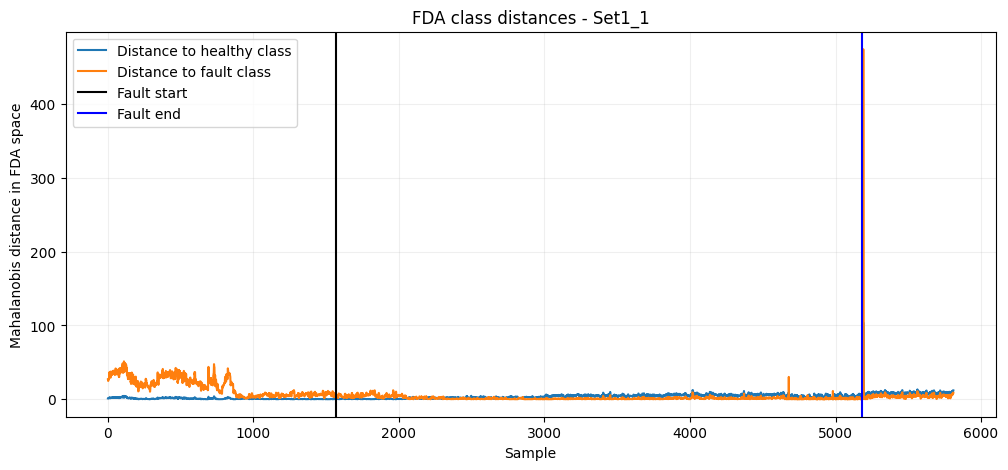

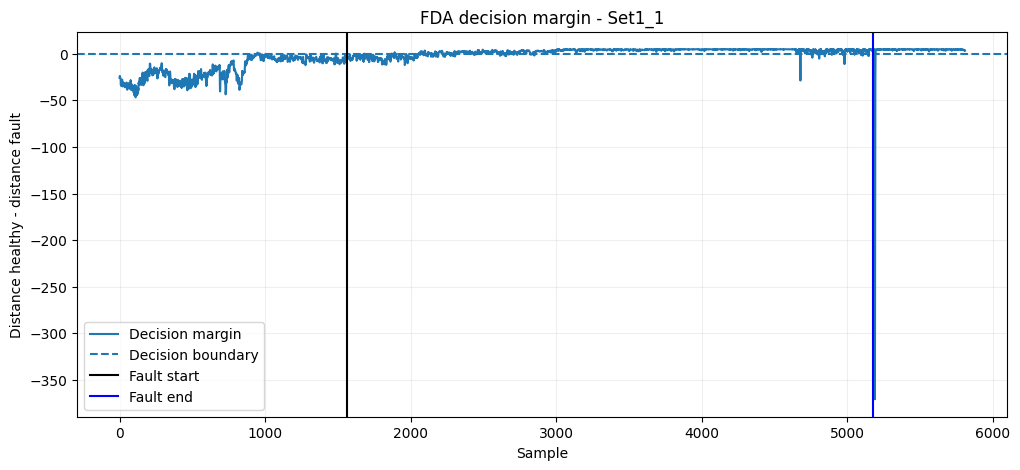

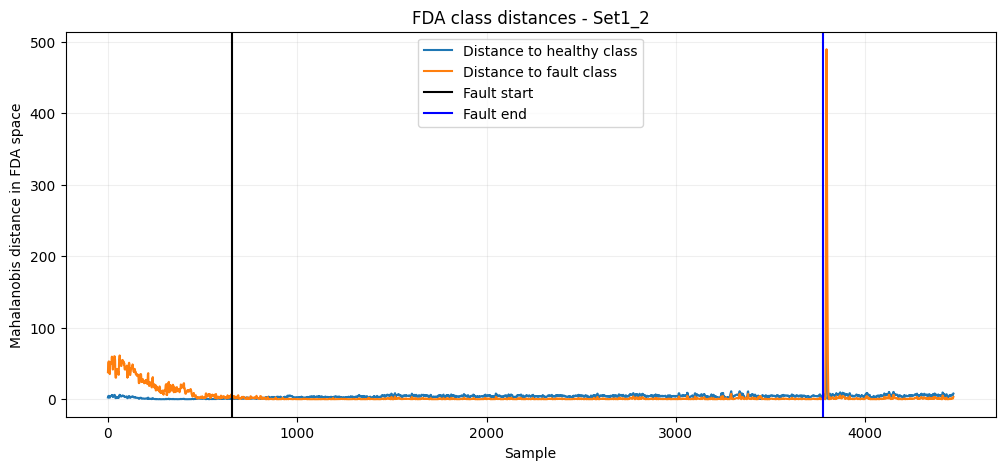

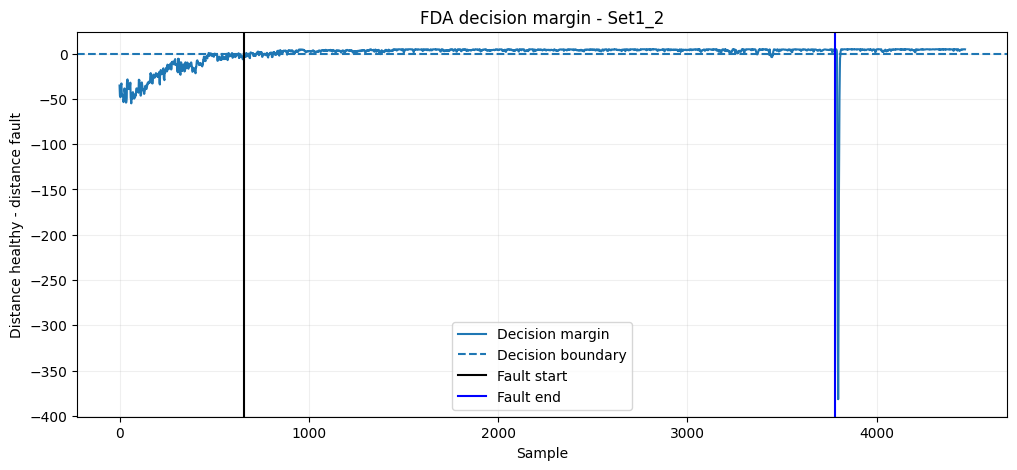

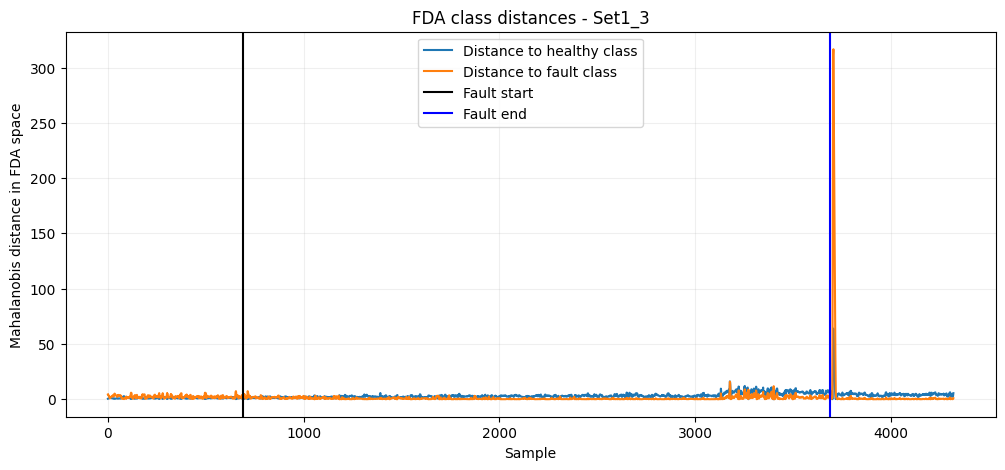

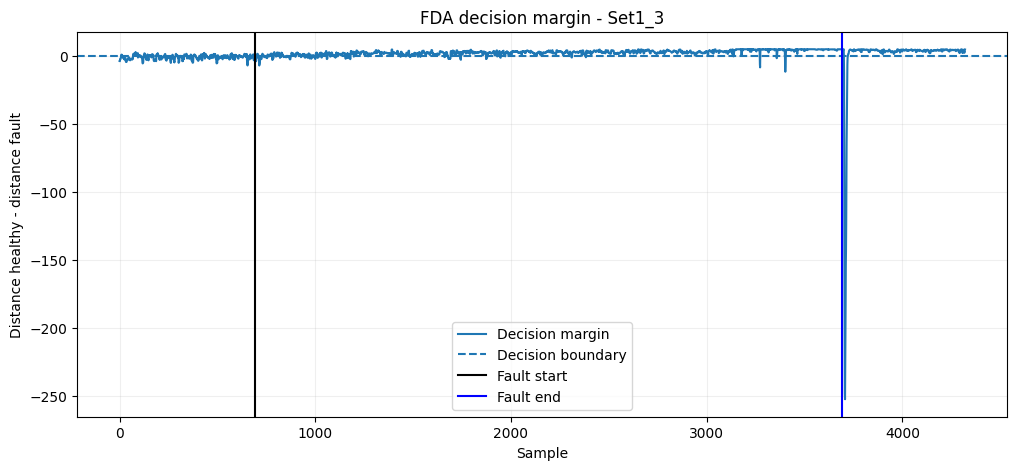

In [21]:
for name, result in fda_diagnostic_results.items():
    fault_start = fault_info[name]["start"]
    fault_end = fault_info[name]["end"]

    plt.figure(figsize=(12, 5))
    plt.plot(result["distance_to_healthy"], label="Distance to healthy class")
    plt.plot(result["distance_to_fault"], label="Distance to fault class")
    plt.axvline(fault_start, color="black", linestyle="-", label="Fault start")
    plt.axvline(fault_end, color="blue", linestyle="-", label="Fault end")
    plt.title(f"FDA class distances - {name}")
    plt.xlabel("Sample")
    plt.ylabel("Mahalanobis distance in FDA space")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(result["decision_margin"], label="Decision margin")
    plt.axhline(0, linestyle="--", label="Decision boundary")
    plt.axvline(fault_start, color="black", linestyle="-", label="Fault start")
    plt.axvline(fault_end, color="blue", linestyle="-", label="Fault end")
    plt.title(f"FDA decision margin - {name}")
    plt.xlabel("Sample")
    plt.ylabel("Distance healthy - distance fault")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

## DPCA diagnostic plot 

Den giver DPCA samme typer plots som PCA
- T2 over tid 
- Q/SPE over tid 
- Binær alarm for T2, Q og samlet alarm 

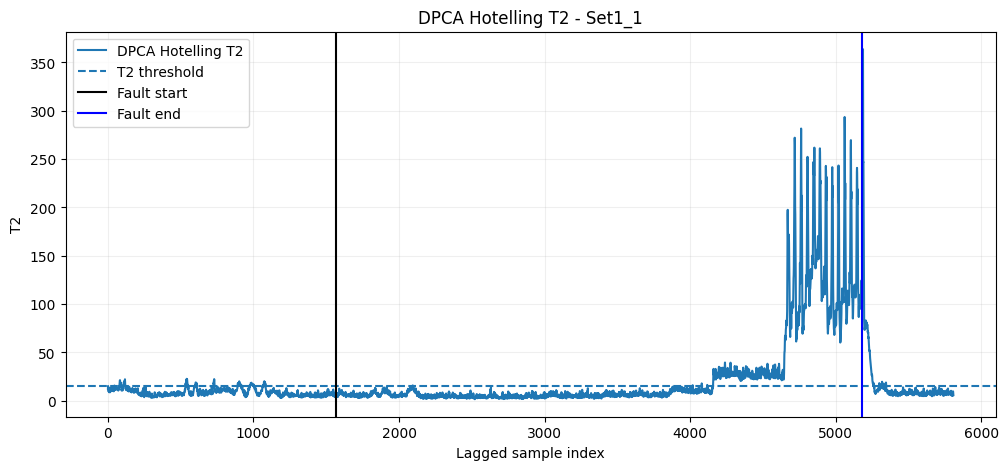

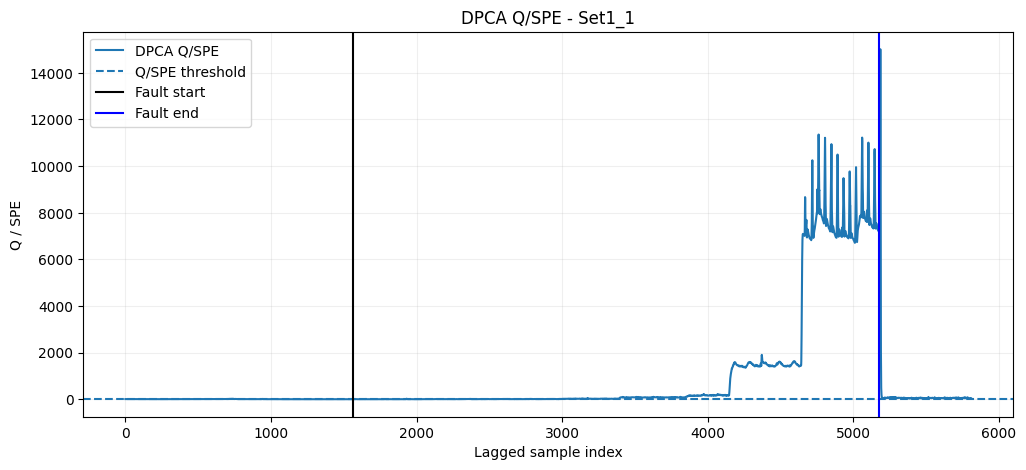

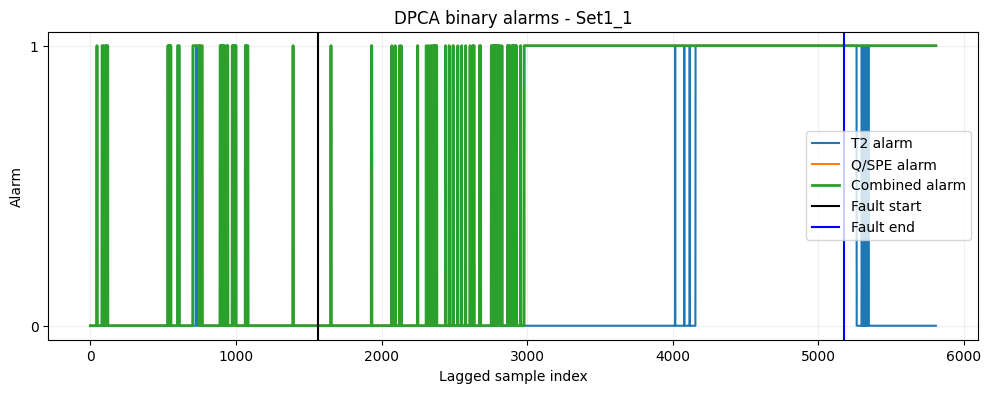

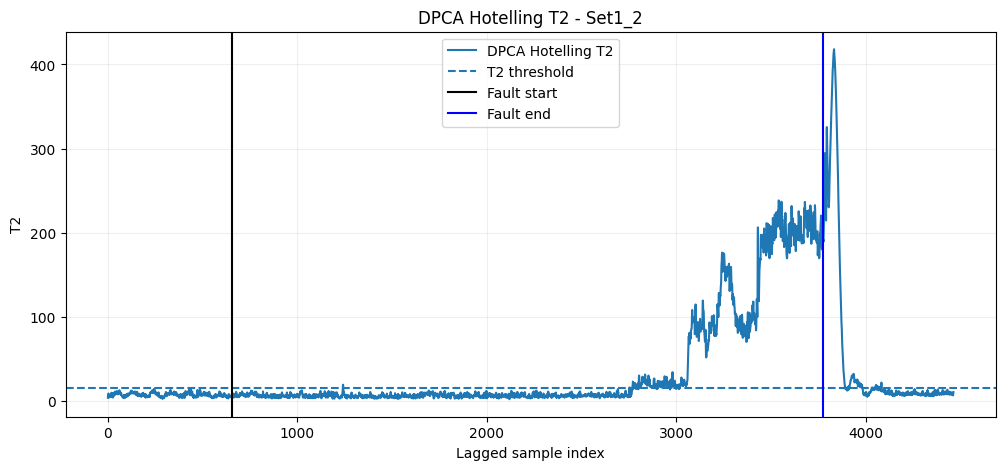

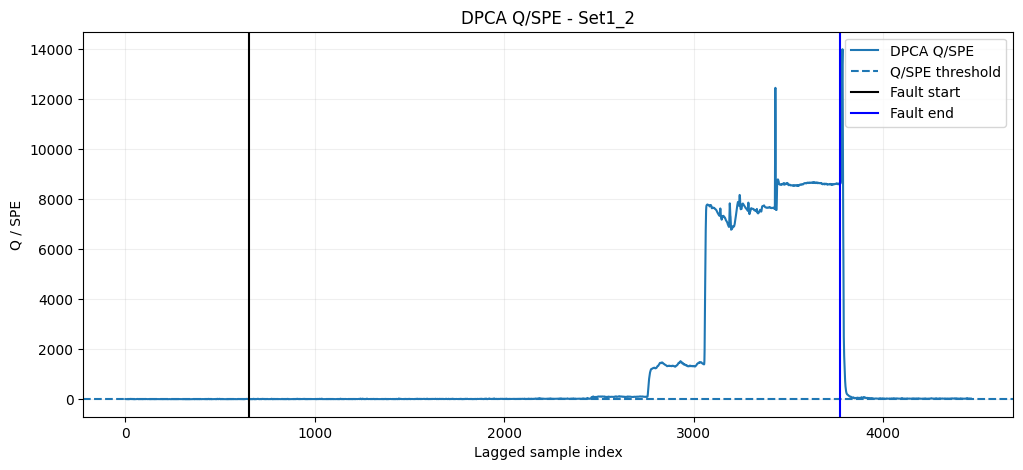

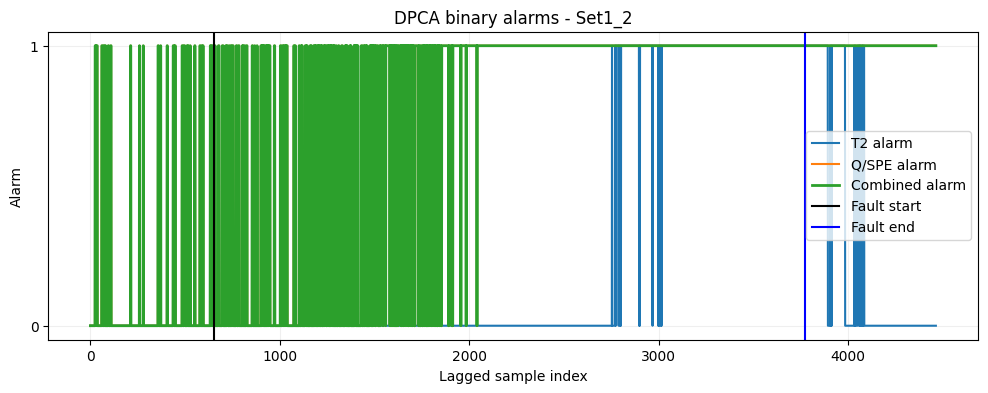

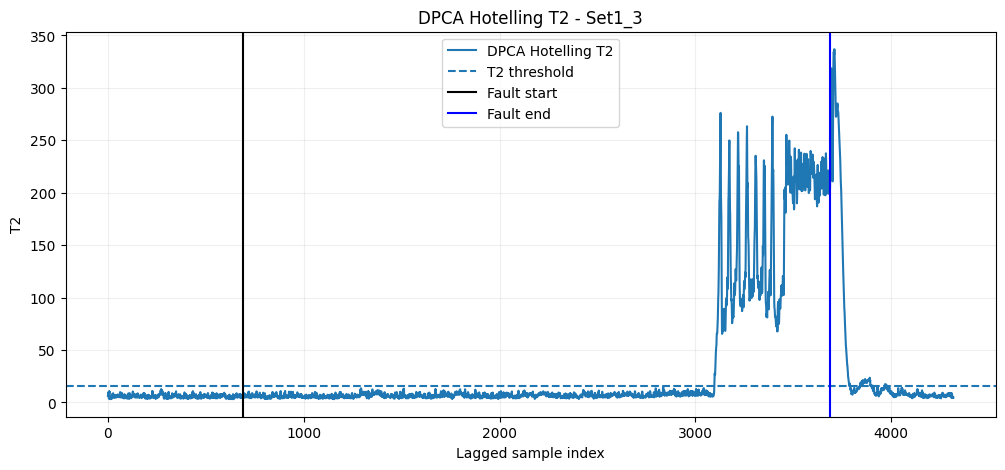

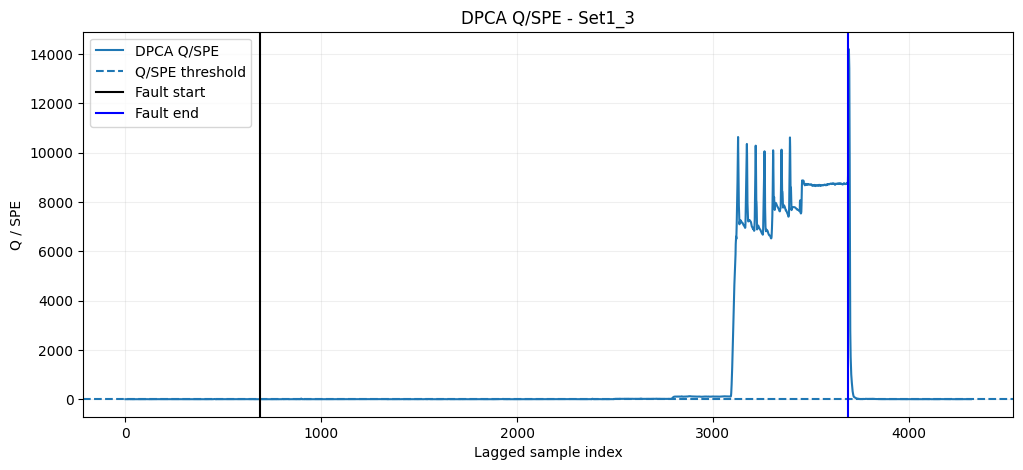

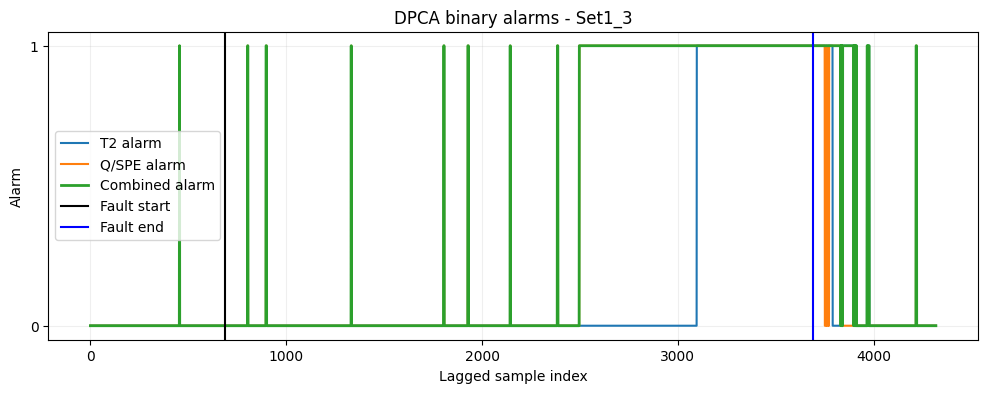

In [30]:
for name, result in dpca_results.items():
    fault_start = result["adjusted_fault_start"]
    fault_end = result["adjusted_fault_end"]

    plt.figure(figsize=(12, 5))
    plt.plot(result["T2"], label="DPCA Hotelling T2")
    plt.axhline(T2_limit_dpca, linestyle="--", label="T2 threshold")
    plt.axvline(fault_start, color="black", linestyle="-", label="Fault start")
    plt.axvline(fault_end, color="blue", linestyle="-", label="Fault end")
    plt.title(f"DPCA Hotelling T2 - {name}")
    plt.xlabel("Lagged sample index")
    plt.ylabel("T2")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(result["Q"], label="DPCA Q/SPE")
    plt.axhline(Q_limit_dpca, linestyle="--", label="Q/SPE threshold")
    plt.axvline(fault_start, color="black", linestyle="-", label="Fault start")
    plt.axvline(fault_end, color="blue", linestyle="-", label="Fault end")
    plt.title(f"DPCA Q/SPE - {name}")
    plt.xlabel("Lagged sample index")
    plt.ylabel("Q / SPE")
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(result["alarm_T2"].astype(int), label="T2 alarm")
    plt.plot(result["alarm_Q"].astype(int), label="Q/SPE alarm")
    plt.plot(result["alarm_combined"].astype(int), label="Combined alarm", linewidth=2)
    plt.axvline(fault_start, color="black", linestyle="-", label="Fault start")
    plt.axvline(fault_end, color="blue", linestyle="-", label="Fault end")
    plt.title(f"DPCA binary alarms - {name}")
    plt.xlabel("Lagged sample index")
    plt.ylabel("Alarm")
    plt.yticks([0, 1])
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

## Detection delay graf 

Denne blok laver en bar chart pr. datasæt, hvor den viser detection_delay.

Det gør det nemt at se, hvilken metode der opdager fejlen hurtigst.

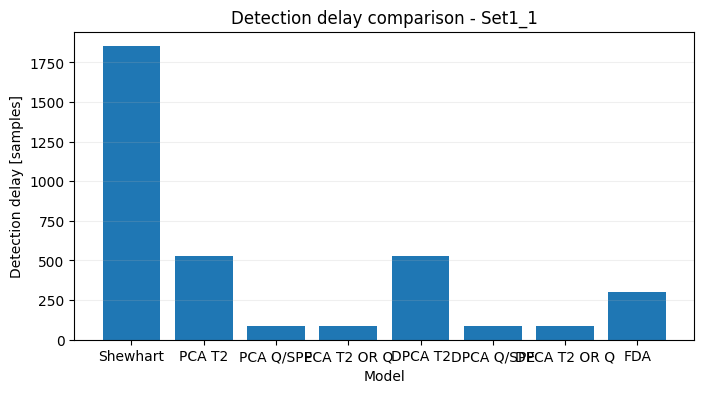

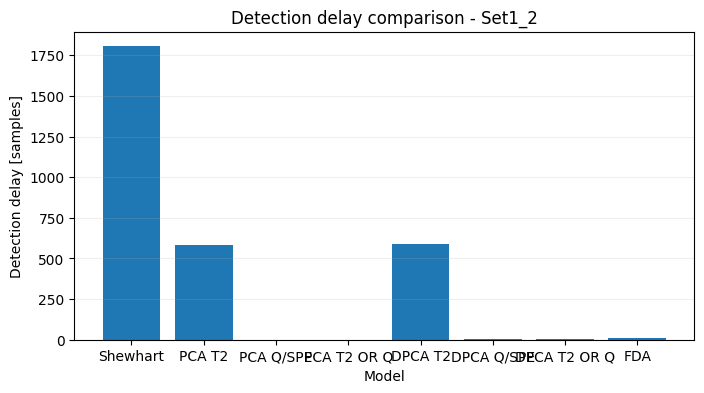

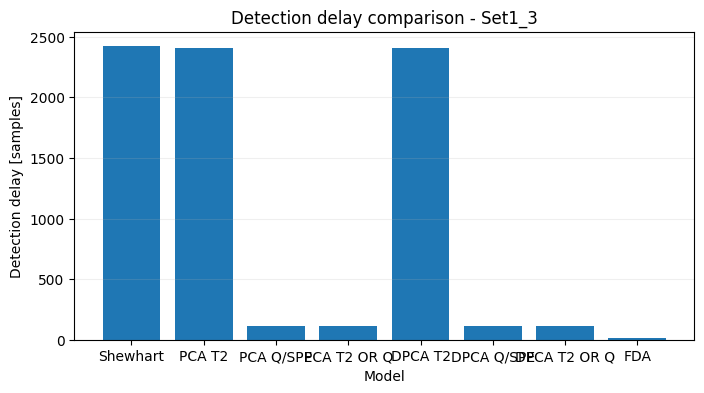

In [31]:
plot_df = comparison_df.copy()
plot_df["detection_delay"] = pd.to_numeric(
    plot_df["detection_delay"],
    errors="coerce",
)

for dataset_name in plot_df["Dataset"].unique():
    subset = plot_df[plot_df["Dataset"] == dataset_name]

    plt.figure(figsize=(8, 4))
    plt.bar(subset["Model"], subset["detection_delay"])
    plt.title(f"Detection delay comparison - {dataset_name}")
    plt.xlabel("Model")
    plt.ylabel("Detection delay [samples]")
    plt.grid(True, axis="y", alpha=0.2)
    plt.show()

## False alarm rate graf

Denne kodeblok sammenligner hvor ofte hver model laver alarm før fejlen starter. Jo lavere værdi, jo bedre

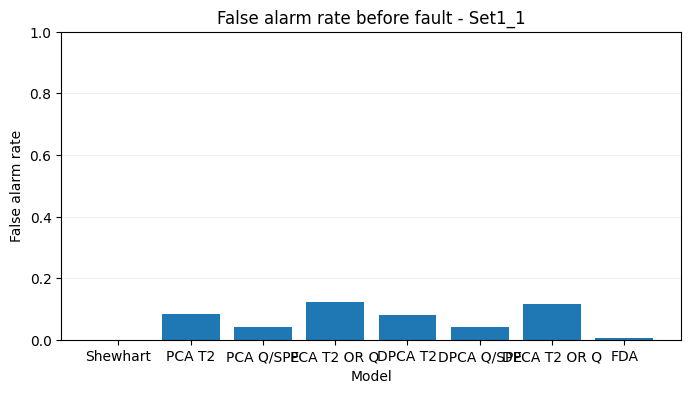

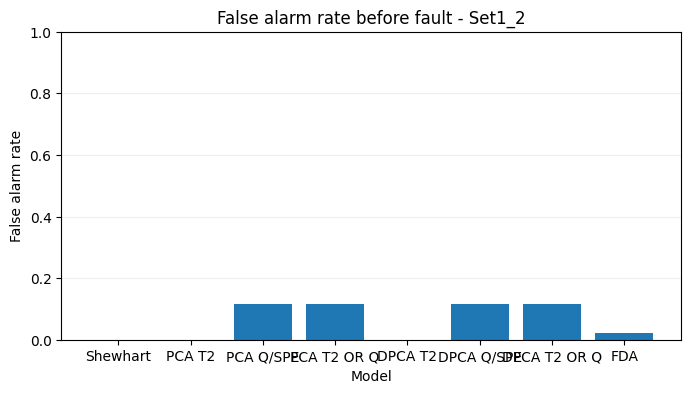

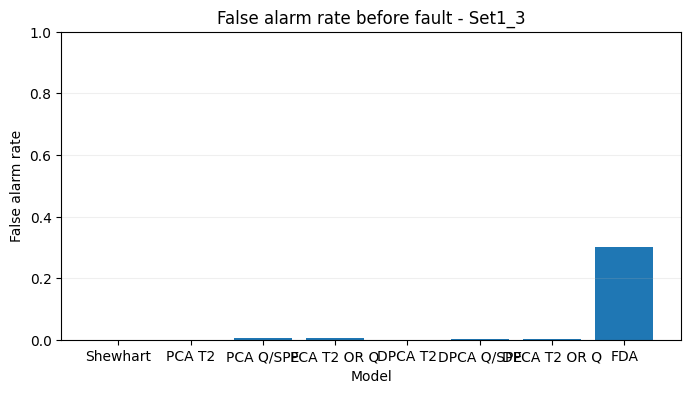

In [32]:
for dataset_name in comparison_df["Dataset"].unique():
    subset = comparison_df[comparison_df["Dataset"] == dataset_name]

    plt.figure(figsize=(8, 4))
    plt.bar(subset["Model"], subset["false_alarm_rate_before_fault"])
    plt.title(f"False alarm rate before fault - {dataset_name}")
    plt.xlabel("Model")
    plt.ylabel("False alarm rate")
    plt.ylim(0, 1)
    plt.grid(True, axis="y", alpha=0.2)
    plt.show()

## Fault detection rate graf 

Denne kodeblok viser hvor stor en del af fault-perioden modellen faktisk opdager. Jo tættere på 1, jo bedre. 

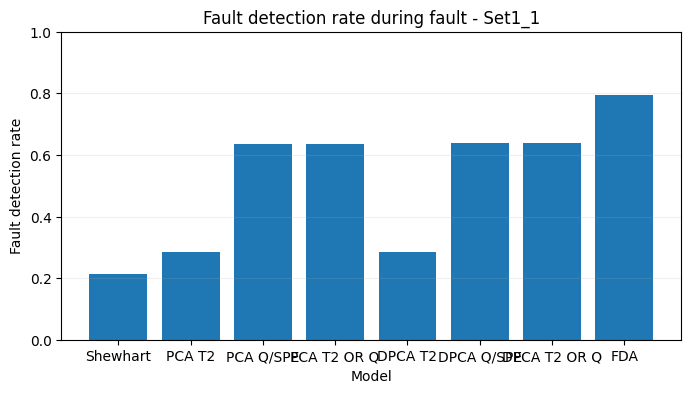

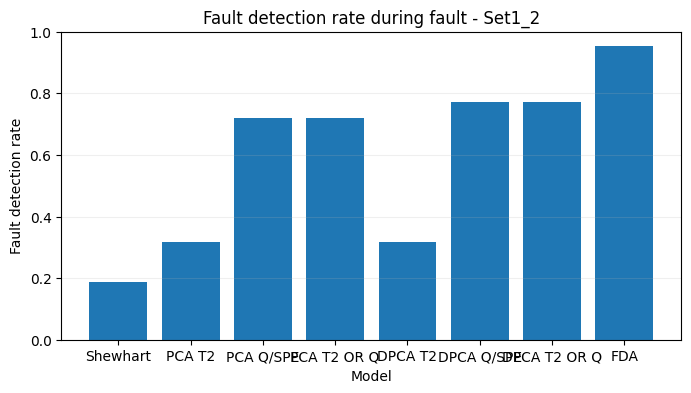

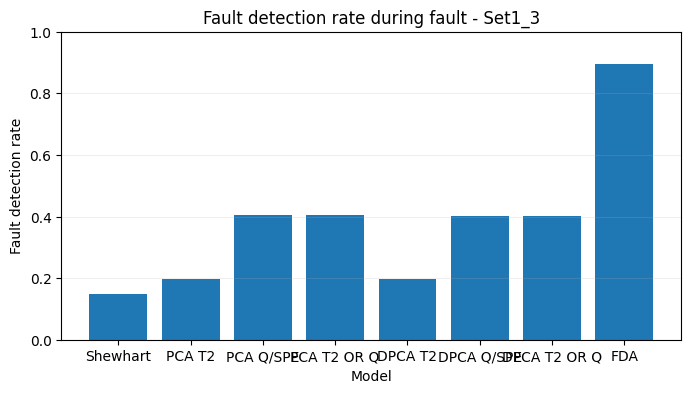

In [33]:
for dataset_name in comparison_df["Dataset"].unique():
    subset = comparison_df[comparison_df["Dataset"] == dataset_name]

    plt.figure(figsize=(8, 4))
    plt.bar(subset["Model"], subset["fault_detection_rate"])
    plt.title(f"Fault detection rate during fault - {dataset_name}")
    plt.xlabel("Model")
    plt.ylabel("Fault detection rate")
    plt.ylim(0, 1)
    plt.grid(True, axis="y", alpha=0.2)
    plt.show()

## Samlet ranking tabel

Denne kodeblok rangerer modellerne pr. datasæt
- Lav detection delay = bedre 
- Lav false alarm rate = bedre 
- Høj fault detection rate = bedre 

Lavest overall_rank_score er bedst

In [34]:
ranking_df = comparison_df.copy()

ranking_df["detection_delay_rank"] = ranking_df.groupby("Dataset")["detection_delay"].rank(
    method="min",
    ascending=True,
    na_option="bottom"
)

ranking_df["false_alarm_rank"] = ranking_df.groupby("Dataset")["false_alarm_rate_before_fault"].rank(
    method="min",
    ascending=True
)

ranking_df["detection_rate_rank"] = ranking_df.groupby("Dataset")["fault_detection_rate"].rank(
    method="min",
    ascending=False
)

ranking_df["overall_rank_score"] = (
    ranking_df["detection_delay_rank"]
    + ranking_df["false_alarm_rank"]
    + ranking_df["detection_rate_rank"]
)

ranking_df = ranking_df.sort_values(
    ["Dataset", "overall_rank_score"]
)

display(ranking_df[
    [
        "Dataset",
        "Model",
        "detection_delay",
        "false_alarm_rate_before_fault",
        "fault_detection_rate",
        "detection_delay_rank",
        "false_alarm_rank",
        "detection_rate_rank",
        "overall_rank_score",
    ]
])

,Dataset,Model,detection_delay,false_alarm_rate_before_fault,fault_detection_rate,detection_delay_rank,false_alarm_rank,detection_rate_rank,overall_rank_score
5,Set1_1,DPCA Q/SPE,88,0.042199,0.638551,1.0,3.0,3.0,7.0
7,Set1_1,FDA,304,0.006386,0.795077,5.0,2.0,1.0,8.0
2,Set1_1,PCA Q/SPE,88,0.042784,0.634679,1.0,4.0,5.0,10.0
6,Set1_1,DPCA T2 OR Q,88,0.117008,0.639104,1.0,7.0,2.0,10.0
3,Set1_1,PCA T2 OR Q,88,0.121967,0.635232,1.0,8.0,4.0,13.0
0,Set1_1,Shewhart,1851,0.000000,0.214049,8.0,1.0,8.0,17.0
4,Set1_1,DPCA T2,529,0.080563,0.284569,6.0,5.0,6.0,17.0
1,Set1_1,PCA T2,529,0.084930,0.284569,6.0,6.0,6.0,18.0
13,Set1_2,DPCA Q/SPE,3,0.114504,0.770907,3.0,5.0,2.0,10.0
14,Set1_2,DPCA T2 OR Q,3,0.114504,0.770907,3.0,5.0,2.0,10.0


## Gennemsnitlig performance på tværs af datasæt

Denne kodeblok sammenligner resultaterne på tværs af Set1_1, Set1_2 og Set1_3. Denne tabel er god til rapporten, fordi den viser hvilken model der generelt klarer sig bedst. 

In [35]:
average_performance_df = comparison_df.groupby("Model").agg(
    mean_detection_delay=("detection_delay", "mean"),
    mean_false_alarm_rate=("false_alarm_rate_before_fault", "mean"),
    mean_fault_detection_rate=("fault_detection_rate", "mean"),
    mean_total_alarms=("n_alarms_total", "mean"),
).reset_index()

display(average_performance_df)

,Model,mean_detection_delay,mean_false_alarm_rate,mean_fault_detection_rate,mean_total_alarms
0,DPCA Q/SPE,68.333333,0.052718,0.603997,2506.000000
1,DPCA T2,1174.333333,0.026854,0.266779,1076.666667
2,DPCA T2 OR Q,68.333333,0.077654,0.604181,2574.333333
3,FDA,109.333333,0.109594,0.881102,3555.666667
4,PCA Q/SPE,67.333333,0.054268,0.586485,2450.000000
5,PCA T2,1174.000000,0.028310,0.266245,1081.666667
6,PCA T2 OR Q,67.333333,0.080662,0.586669,2521.333333
7,Shewhart,2025.333333,0.000000,0.183262,644.666667


## Gennemsnitlig performance grafer 

Denne kodeblok laver grafer for gennemsnitlig perfomance på tværs af datasættet. Det gør det lettere at diskutere modellerne samlet i rapporten

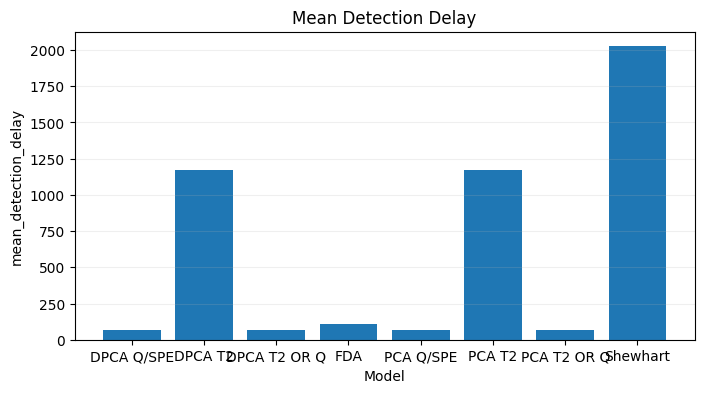

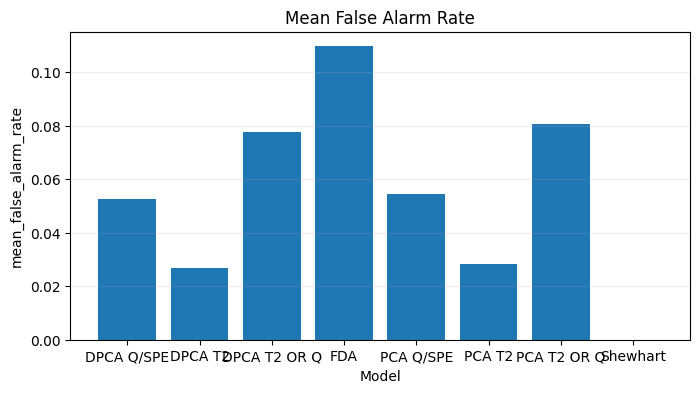

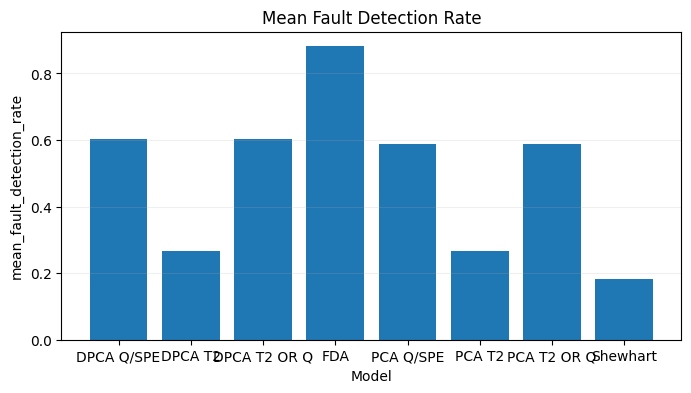

In [36]:
metrics_to_plot = [
    "mean_detection_delay",
    "mean_false_alarm_rate",
    "mean_fault_detection_rate",
]

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 4))
    plt.bar(average_performance_df["Model"], average_performance_df[metric])
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.grid(True, axis="y", alpha=0.2)
    plt.show()